# UpSet Plot - Building Blocks Analysis for ChEMBL-100

This notebook generates the UpSet plot showing union coverage of building blocks across different retrosynthesis search algorithms.

**Prerequisites:** The building blocks parquet files must already be extracted (run `4_extract_building_blocks_nested_list.py` first if needed).

In [1]:
from pathlib import Path

# Get the current directory as a Path object
current_dir = Path.cwd()

# Get the parent directory
repository_directory = current_dir.parent
result_path = str(repository_directory) +   "/data/results/azf/chembl100/"
save_path = str(repository_directory) +  "/visualizations"

print(f"Repository Directory:  {repository_directory}")
print(f"Result Path:  {result_path}")
print(f"Save Path:  {save_path}")

Repository Directory:  /Users/alankaihassen/development/diversity_search_rebuttal/updated_code/SPRS/results
Result Path:  /Users/alankaihassen/development/diversity_search_rebuttal/updated_code/SPRS/results/data/results/azf/chembl100/
Save Path:  /Users/alankaihassen/development/diversity_search_rebuttal/updated_code/SPRS/results/visualizations


In [2]:
def find_algorithm(key):
    if "0_chembl100_default_retrostar_0" in key:
        return "Retro*-0"
    elif "1_chembl100_default_mcts" in key:
        return "MCTS"
    elif "2_chembl100_diversity_forcing_mcts" in key:
        return "Distance-MCTS"
    elif "3_chembl100_expansion_clustering_mcts" in key:
        # expansion_clustering_mcts
        return "Cluster-MCTS"
    elif "4_chembl100_expansion_clustering_retrostar_0" in key:
        # expansion_clustering_retrostar
        return "Cluster-Retro*-0"
    else:
        raise ValueError(f"Could not map key {key} to an algorithm")

In [3]:
from pathlib import Path
import pandas as pd

# Get the building_blocks_nested directory
building_blocks_nested_dir = Path(save_path) / "building_blocks_nested"

# Load all parquet files in the building_blocks_nested directory
all_building_blocks = {}

for parquet_file in building_blocks_nested_dir.glob("*_building_blocks.parquet"):
    # Extract the key name (remove _building_blocks.parquet suffix)
    key = find_algorithm(str(parquet_file))
    
    # Load the parquet file (nested lists are preserved automatically)
    df = pd.read_parquet(parquet_file)
    
    # Store in dictionary
    all_building_blocks[key] = df
    
    print(f"Loaded {key}: {len(df)} molecules, {df['num_routes'].sum()} total routes")

# Sort the dictionary by keys of algorithm_order

# Display summary
print(f"\n{'='*80}")
print("SUMMARY")
print(f"{'='*80}")
print(f"Total datasets loaded: {len(all_building_blocks)}")
print(f"Available keys: {list(all_building_blocks.keys())}")

all_building_blocks["Retro*-0"]

Loaded Cluster-Retro*-0: 100 molecules, 165443 total routes
Loaded Distance-MCTS: 100 molecules, 243260 total routes
Loaded Distance-MCTS: 100 molecules, 243260 total routes
Loaded MCTS: 100 molecules, 272506 total routes
Loaded MCTS: 100 molecules, 272506 total routes
Loaded Cluster-MCTS: 100 molecules, 25819 total routes
Loaded Cluster-MCTS: 100 molecules, 25819 total routes
Loaded Retro*-0: 100 molecules, 170605 total routes

SUMMARY
Total datasets loaded: 5
Available keys: ['Cluster-Retro*-0', 'Distance-MCTS', 'MCTS', 'Cluster-MCTS', 'Retro*-0']
Loaded Retro*-0: 100 molecules, 170605 total routes

SUMMARY
Total datasets loaded: 5
Available keys: ['Cluster-Retro*-0', 'Distance-MCTS', 'MCTS', 'Cluster-MCTS', 'Retro*-0']


,index,target,search_time,first_solution_time,first_solution_iteration,number_of_nodes,max_transforms,max_children,number_of_routes,number_of_solved_routes,...,precursors_availability,policy_used_counts,profiling,cluster_labels,cluster_time,distance_matrix,stock_info,top_scores,solved_routes_building_blocks_nested,num_routes
0,0,CC(=O)c1ccc(-c2sc3cc(O)ccc3c2C(=O)c2ccc(OCCN3C...,7052.093831,6.928230,6,1006626,15,82,23979,1843,...,emolecules;emolecules;emolecules,{'retrostar_mlp': 158033},"{'expansion_calls': 25000, 'reactants_generati...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1.481905,"[[0.0, 4.056214687790253, 4.587610975118744, 4...","{'B': None, 'Br': ['emolecules'], 'BrBr': ['em...","0.9940, 0.9940, 0.9940, 0.9940, 0.9940, 0.9866...","[[CC(=O)c1ccc(Br)cc1, COc1ccc2cc(B(O)O)sc2c1, ...",1843
1,1,O=C(NCCCCN1CCC(c2cccc3ccccc23)CC1)c1ccc(-c2ccc...,6331.040757,4.892638,2,942245,16,97,21604,1188,...,emolecules;emolecules;emolecules,{'retrostar_mlp': 121390},"{'expansion_calls': 25000, 'reactants_generati...","[0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, ...",1.474309,"[[0.0, 0.6413043478260869, 1.5241935483870968,...","{'B': None, 'Br': ['emolecules'], 'BrBr': None...","0.9940, 0.9940, 0.9940, 0.9940, 0.9940, 0.9940...","[[c1ccc2c(C3CCNCC3)cccc2c1, NCCCCBr, O=C(O)c1c...",1188
2,2,O=C(NCc1cccc(-c2cccc(-c3cc4c[nH]ccc-4n3)c2O)c1...,6007.997541,13.575945,25,861912,16,79,25035,278,...,emolecules;emolecules;emolecules;emolecules,{'retrostar_mlp': 150756},"{'expansion_calls': 25000, 'reactants_generati...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1.759273,"[[0.0, 1.1733333333333333, 4.186047993125849, ...","{'B': None, 'Br': ['emolecules'], 'BrBr': ['em...","0.9866, 0.9866, 0.9866, 0.9866, 0.9866, 0.9866...","[[COB(OC)OC, Brc1cc2c[nH]ccc-2n1, OB(O)c1cccc(...",278
3,3,CN(C)CCCNC(=O)c1cc(NC(=O)c2cc(NC(=O)c3ccc(N(CC...,4327.980053,5.384270,6,825962,15,126,23552,1467,...,emolecules;emolecules;emolecules,{'retrostar_mlp': 172777},"{'expansion_calls': 25000, 'reactants_generati...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, ...",1.799975,"[[0.0, 7.232663702763068, 7.255273521884514, 7...","{'B': None, 'Br': ['emolecules'], 'BrBr': None...","0.9940, 0.9866, 0.9866, 0.9866, 0.9866, 0.9866...","[[NC(=O)c1ccc(N(CCCl)CCCl)cc1, CN(C)CCCNC(=O)c...",1467
4,4,O=C(CN1C(=O)Cc2c([nH]c3ccc(Br)cc23)-c2ccc(Cl)c...,5843.571136,4.503498,4,913337,16,77,23749,1244,...,emolecules;emolecules;emolecules;emolecules,{'retrostar_mlp': 142074},"{'expansion_calls': 25000, 'reactants_generati...","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 0, ...",1.421775,"[[0.0, 2.6470238095238097, 5.270012315270936, ...","{'B': None, 'Br': ['emolecules'], 'BrBr': ['em...","0.9940, 0.9940, 0.9940, 0.9940, 0.9940, 0.9940...","[[[I-], O=C(CBr)NCc1ccccc1, O=C1CCC(=O)N1Cl, O...",1239
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,95,CN1CCN(CCCOc2ccc(N3C(=O)C(=Cc4ccc(Oc5ccc([N+](...,7200.328327,4.433981,2,1317101,17,74,18702,2368,...,emolecules;emolecules;emolecules;emolecules,{'retrostar_mlp': 109125},"{'expansion_calls': 24634, 'reactants_generati...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1.378024,"[[0.0, 1.1663615560640732, 3.343751060436391, ...","{'B': None, 'Br': ['emolecules'], 'BrBr': ['em...","0.9940, 0.9940, 0.9940, 0.9940, 0.9940, 0.9940...","[[CS(=O)(=O)Cl, CN1CCN(CCCO)CC1, O=[N+]([O-])c...",2368
96,96,O=C(OCCCO[N+](=O)[O-])C1OC(Oc2cc3oc(-c4ccc(OCc...,7200.301584,25.472178,37,875958,11,101,25012,94,...,emolecules;emolecules;emolecules;emolecules;em...,{'retrostar_mlp': 110838},"{'expansion_calls': 22423, 'reactants_generati...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",1.958258,"[[0.0, 2.6403162055335967, 0.8529411764705883,...","{'B': None, 'Br': None, 'BrBr': None, 'BrC(Br)...","0.9866, 0.9866, 0.9866, 0.9866, 0.9866, 0.9866...","[[BrCc1ccccc1, O=[N+]([O-])O, OCCCO, OCc1ccccc...",94
97,97,Cn1cc(S(=O)(=O)NCCOc2ccc3c(c2)C(C2(c4ccc(Cl)cc...,5644.714821,6.483392,6,631221,15,61,24930,1

In [4]:
algorithm_order = [
    'MCTS',
    'Distance-MCTS',
    'Cluster-MCTS',
    'Retro*-0',
    'Cluster-Retro*-0'
]

# Sort the dictionary according to algorithm_order
all_building_blocks = {key: all_building_blocks[key] for key in algorithm_order if key in all_building_blocks}

print(f"Sorted dictionary keys: {list(all_building_blocks.keys())}")

Sorted dictionary keys: ['MCTS', 'Distance-MCTS', 'Cluster-MCTS', 'Retro*-0', 'Cluster-Retro*-0']


In [5]:
from rdkit import Chem

def smiles_to_inchi_key(smiles):
    """Convert a single SMILES to InChI key"""
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is not None:
            return Chem.MolToInchiKey(mol)
        else:
            raise ValueError("Invalid SMILES")
    except:
        raise ValueError("Conversion failed")

def nested_smiles_to_inchi_keys(nested_list):
    """Convert nested list of SMILES to nested list of InChI keys"""
    return [[smiles_to_inchi_key(smiles) for smiles in route_bbs] for route_bbs in nested_list]

def get_unique_building_block_sets(list_of_routes):
    """
    Takes a list of routes (where each route is a list of InChI keys)
    and returns a new list containing only the unique sets of building blocks.
    
    Example:
    Input:  [['A','B'], ['A','B','C'], ['B','A'], ['A','B']]
    Output: [['A','B'], ['A','B','C']] 
            (Order of lists in the output doesn't matter)
    """
    
    # This set will store the unique combinations we've seen.
    # We use frozenset because sets are "hashable" and can be
    # added to other sets, unlike lists.
    seen_combinations = set()
    
    # This list will hold our final, unique routes.
    unique_routes_list = []
    
    for route in list_of_routes:
        # 1. Create a frozenset from the route.
        # This ignores order ('B','A' becomes same as 'A','B')
        # and internal duplicates ('A','B','A' becomes same as 'A','B').
        route_as_set = frozenset(route)
        
        # 2. Check if we have already seen this combination.
        if route_as_set not in seen_combinations:
            
            # 3. If not, add it to our 'seen' set.
            seen_combinations.add(route_as_set)
            
            # 4. And add a clean, sorted version of the route
            #    to our final list. We sort it to have a nice,
            #    canonical representation (e.g., always ['A','B'] not ['B','A']).
            unique_routes_list.append(sorted(list(route_as_set)))
            
    return unique_routes_list

# Add InChI key column for nested building blocks only
for key, df in all_building_blocks.items():
    print(f"Processing InChI keys for {key}...")
    
    # Convert nested building blocks to nested InChI keys (preserves route structure)
    df['solved_routes_building_blocks_nested_inchi_keys'] = df['solved_routes_building_blocks_nested'].apply(nested_smiles_to_inchi_keys)
    
    # Count how many InChI keys are valid
    total_bbs = sum(sum(len(route) for route in nested) for nested in df['solved_routes_building_blocks_nested'])
    valid_inchi = sum(sum(sum(1 for ik in route if ik is not None) for route in nested) for nested in df['solved_routes_building_blocks_nested_inchi_keys'])
    
    print(f"  - Total building blocks: {total_bbs}")
    print(f"  - Valid InChI keys: {valid_inchi}")
    
    if total_bbs > valid_inchi:
        print(f"  - Failed conversions: {total_bbs - valid_inchi}")

    # Deduplicate InChI keys within each route list as we are only interested in unique building block combinations used.
    # This means that routes that rely on the same building block but are different in the order will count exactly once.

    df['solved_routes_building_blocks_nested_inchi_keys_deduplicated_lists'] = df['solved_routes_building_blocks_nested_inchi_keys'].apply(get_unique_building_block_sets)
    df['num_routes_deduplicated'] = df['solved_routes_building_blocks_nested_inchi_keys_deduplicated_lists'].apply(len)

    # rename the num_routes column to num_routes_original for clarity
    df.rename(columns={'num_routes': 'num_routes_original'}, inplace=True)

    # Statistics: Count total BBs after deduplication
    total_bbs_after_dedup = sum(len(route) for nested in df['solved_routes_building_blocks_nested_inchi_keys_deduplicated_lists'] for route in nested)
    num_routes_before = sum(len(nested) for nested in df['solved_routes_building_blocks_nested_inchi_keys'])
    num_routes_after = sum(len(nested) for nested in df['solved_routes_building_blocks_nested_inchi_keys_deduplicated_lists'])
    
    print(f"  - Routes before deduplication: {num_routes_before}")
    print(f"  - Routes after deduplication: {num_routes_after}")
    print(f"  - Total building blocks in deduplicated routes: {total_bbs_after_dedup}")

all_building_blocks["MCTS"]

Processing InChI keys for MCTS...
  - Total building blocks: 1918636
  - Valid InChI keys: 1918636
  - Total building blocks: 1918636
  - Valid InChI keys: 1918636
  - Routes before deduplication: 272506
  - Routes after deduplication: 205745
  - Total building blocks in deduplicated routes: 1430221
Processing InChI keys for Distance-MCTS...
  - Routes before deduplication: 272506
  - Routes after deduplication: 205745
  - Total building blocks in deduplicated routes: 1430221
Processing InChI keys for Distance-MCTS...
  - Total building blocks: 1742503
  - Valid InChI keys: 1742503
  - Total building blocks: 1742503
  - Valid InChI keys: 1742503
  - Routes before deduplication: 243260
  - Routes after deduplication: 160934
  - Total building blocks in deduplicated routes: 1118504
Processing InChI keys for Cluster-MCTS...
  - Routes before deduplication: 243260
  - Routes after deduplication: 160934
  - Total building blocks in deduplicated routes: 1118504
Processing InChI keys for Clus

,index,target,search_time,first_solution_time,first_solution_iteration,number_of_nodes,max_transforms,max_children,number_of_routes,number_of_solved_routes,...,cluster_labels,cluster_time,distance_matrix,stock_info,top_scores,solved_routes_building_blocks_nested,num_routes_original,solved_routes_building_blocks_nested_inchi_keys,solved_routes_building_blocks_nested_inchi_keys_deduplicated_lists,num_routes_deduplicated
0,0,CC(=O)c1ccc(-c2sc3cc(O)ccc3c2C(=O)c2ccc(OCCN3C...,4398.530200,51.957295,1,99371,30,93,96128,4167,...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, ...",8.158752,"[[0.0, 0.7681159420289855, 1.68756038647343, 1...","{'B': None, 'Br': ['emolecules'], 'BrBr': ['em...","0.9940, 0.9940, 0.9940, 0.9940, 0.9940, 0.9940...","[[O=C(Cl)c1ccc(OCCN2CCCCC2)cc1, COc1ccc2cc(B(O...",4167,"[[QGKJLTUHTANSOU-UHFFFAOYSA-N, PNRDOYJXKKKYSU-...","[[JZJWCDQGIPQBAO-UHFFFAOYSA-N, PNRDOYJXKKKYSU-...",3018
1,1,O=C(NCCCCN1CCC(c2cccc3ccccc23)CC1)c1ccc(-c2ccc...,5352.101914,152.162930,1,151881,30,128,146564,3965,...,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, ...",7.106539,"[[0.0, 0.9882352941176471, 2.3777173913043477,...","{'B': None, 'Br': ['emolecules'], 'BrBr': ['em...","0.9940, 0.9940, 0.9940, 0.9940, 0.9940, 0.9940...","[[NCCCCBr, c1ccc2c(C3CCNCC3)cccc2c1, O=C(Cl)c1...",3895,"[[MVZBYZAIKPPGSW-UHFFFAOYSA-N, SSSBLYQLIOQJSB-...","[[CYIGYCMQCJGBEE-UHFFFAOYSA-N, MVZBYZAIKPPGSW-...",3169
2,2,O=C(NCc1cccc(-c2cccc(-c3cc4c[nH]ccc-4n3)c2O)c1...,7201.377687,1289.084187,19,166860,30,81,158235,879,...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",4.634415,"[[0.0, 0.7586206896551724, 2.805418719211823, ...","{'B': ['emolecules'], 'Br': None, 'BrBr': ['em...","0.9866, 0.9866, 0.9866, 0.9866, 0.9866, 0.9866...","[[Brc1cc2c[nH]ccc-2n1, COc1c(Br)cccc1B(O)O, NC...",875,"[[OFCLQVNMLZZZLX-UHFFFAOYSA-N, KSYYRNDZOSXTFU-...","[[FQDDBYGPHUUTRN-UHFFFAOYSA-N, KSYYRNDZOSXTFU-...",745
3,3,CN(C)CCCNC(=O)c1cc(NC(=O)c2cc(NC(=O)c3ccc(N(CC...,3910.418370,213.444569,10,157003,30,226,152499,1827,...,"[2, 2, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, ...",4.482391,"[[0.0, 2.5275, 0.8193979933110368, 2.718400218...","{'B': None, 'Br': ['emolecules'], 'BrBr': ['em...","0.9940, 0.9940, 0.9940, 0.9940, 0.9940, 0.9940...","[[ClCCNCCCl, O=C(Cl)c1ccc(F)cc1, Cn1cc(N)cc1C(...",1787,"[[TXFLGZOGNOOEFZ-UHFFFAOYSA-N, CZKLEJHVLCMVQR-...","[[CZKLEJHVLCMVQR-UHFFFAOYSA-N, MUEOQEUSJMFYHV-...",1475
4,4,O=C(CN1C(=O)Cc2c([nH]c3ccc(Br)cc23)-c2ccc(Cl)c...,5233.868415,19.376062,1,102277,30,71,98344,3146,...,"[0, 0, 0, 0, 0, 0, 0, 0, 4, 4, 4, 4, 4, 4, 4, ...",8.125868,"[[0.0, 0.6150978564771669, 3.7340071877807723,...","{'B': None, 'Br': ['emolecules'], 'BrBr': ['em...","0.9940, 0.9940, 0.9940, 0.9940, 0.9940, 0.9940...","[[NNc1ccc(Br)cc1, O=C1CCC(=O)c2ccc(Cl)cc2N1, O...",3082,"[[NRESDXFFSNBDGP-UHFFFAOYSA-N, BUYMLVMIVKWJSQ-...","[[BUYMLVMIVKWJSQ-UHFFFAOYSA-N, NRESDXFFSNBDGP-...",2297
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,95,CN1CCN(CCCOc2ccc(N3C(=O)C(=Cc4ccc(Oc5ccc([N+](...,3453.919355,15.574428,1,71400,30,82,69136,5437,...,"[1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...",8.505986,"[[0.0, 2.526829268292683, 2.466044954567193, 2...","{'B': None, 'Br': ['emolecules'], 'BrBr': ['em...","0.9940, 0.9940, 0.9940, 0.9940, 0.9940, 0.9940...","[[O=Cc1ccc(Oc2ccc([N+](=O)[O-])cc2)cc1, O=C(O)...",5427,"[[OCHOSUFDGPHRJA-UHFFFAOYSA-N, GQECANUIPBFPLA-...","[[AHACBCCMXMDLCU-UHFFFAOYSA-N, GQECANUIPBFPLA-...",4466
96,96,O=C(OCCCO[N+](=O)[O-])C1OC(Oc2cc3oc(-c4ccc(OCc...,7463.489973,0.000000,0,47680,30,184,46286,16,...,"[0, 0, 0, 0, 0, 0, 4, 4, 1, 1, 3, 3, 3, 2, 2, 2]",1.092719,"[[0.0, 0.9263157894736842, 0.9263157894736842,...","{'B': None, 'Br': None, 'BrBr': None, 'BrC(Br)...","0.9560, 0.9560, 0.9560, 0.9560, 0.9560, 0.9560...","[[O=[N+]([O-])O, CC(=O)OCCCO, O=C(O)C1OC(O)C(O...",16,"[[GRYLNZFGIOXLOG-UHFFFAOYSA-N, DOUBAFNWVFAWEC-...","[[AEMOLEFTQBMNLQ-UHFFFAOYSA-N, DOUBAFNWVFAWEC-...",15
97,97,Cn1cc(S(=O)(=O)NCCOc2ccc3c(c2)C(C2(c4ccc(Cl)cc...,6761.8662

In [6]:
# Flatten and get unique InChI keys per molecule
for key, df in all_building_blocks.items():
    print(f"Processing unique InChI keys for {key}...")
    
    # Flatten the nested InChI keys and get unique values per molecule
    df['unique_building_blocks_inchi_keys'] = df['solved_routes_building_blocks_nested_inchi_keys_deduplicated_lists'].apply(
        lambda nested_list: list(set([inchi for route_inchi in nested_list for inchi in route_inchi if inchi is not None]))
    )
    
    # Count the number of unique building blocks per molecule
    df['num_unique_building_blocks'] = df['unique_building_blocks_inchi_keys'].apply(len)
    
    print(f"  - Average unique BBs per molecule: {df['num_unique_building_blocks'].mean():.2f}")
    print(f"  - Min unique BBs: {df['num_unique_building_blocks'].min()}")
    print(f"  - Max unique BBs: {df['num_unique_building_blocks'].max()}")

Processing unique InChI keys for MCTS...
  - Average unique BBs per molecule: 322.71
  - Min unique BBs: 19
  - Max unique BBs: 901
Processing unique InChI keys for Distance-MCTS...
  - Average unique BBs per molecule: 300.34
  - Min unique BBs: 29
  - Max unique BBs: 768
Processing unique InChI keys for Cluster-MCTS...
  - Average unique BBs per molecule: 87.36
  - Min unique BBs: 2
  - Max unique BBs: 208
Processing unique InChI keys for Retro*-0...
  - Average unique BBs per molecule: 225.64
  - Min unique BBs: 15
  - Max unique BBs: 800
Processing unique InChI keys for Cluster-Retro*-0...
  - Average unique BBs per molecule: 173.58
  - Min unique BBs: 2
  - Max unique BBs: 685


MCTS: 16443 unique building blocks
Distance-MCTS: 16058 unique building blocks
Cluster-MCTS: 4917 unique building blocks
Retro*-0: 12266 unique building blocks
Cluster-Retro*-0: 9954 unique building blocks

Total unique building blocks across all methods: 28260

Generating all algorithm combinations and calculating union coverage...
Generated 31 combinations (expected: 31)

Creating UpSet plot (Union Coverage % on Top, Absolute Counts on Left)...

Plot saved to /Users/alankaihassen/development/diversity_search_rebuttal/updated_code/SPRS/results/visualizations/3_100_chembl_building_blocks_upset_plot_union_coverage_top_percent_NEW_METHOD.pdf


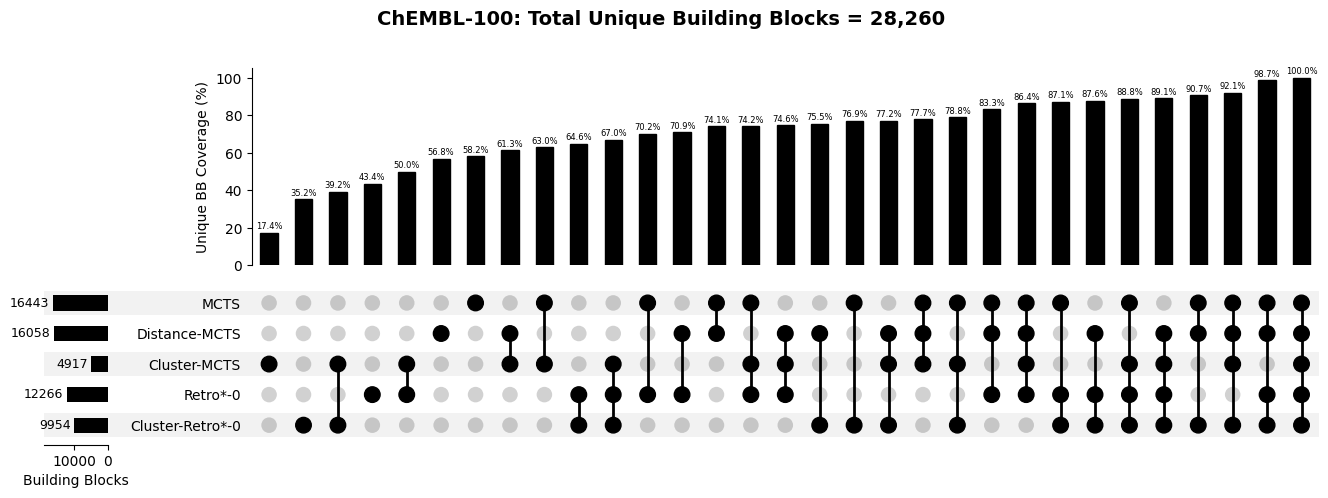


VERIFICATION: Left bar values (absolute BB counts per algorithm)
MCTS: 16443 unique building blocks
Distance-MCTS: 16058 unique building blocks
Cluster-MCTS: 4917 unique building blocks
Retro*-0: 12266 unique building blocks
Cluster-Retro*-0: 9954 unique building blocks


In [ ]:
import matplotlib.pyplot as plt
from upsetplot import UpSet
import pandas as pd
from itertools import combinations

# ==============================================================================
# STEP 1: Get all unique building blocks per method (across all molecules)
# ==============================================================================

print("Collecting all building blocks per method...")

methods = algorithm_order  # Use the defined algorithm order
all_bbs_per_method = {}

for method in methods:
    df = all_building_blocks[method]
    # Collect all unique InChI keys across all molecules for this method
    all_inchi_keys = set()
    for inchi_list in df['unique_building_blocks_inchi_keys']:
        all_inchi_keys.update(inchi_list)
    all_bbs_per_method[method] = all_inchi_keys
    print(f"{method}: {len(all_inchi_keys)} unique building blocks")

# Calculate total unique BBs across ALL methods
all_bbs_combined = set()
for bbs in all_bbs_per_method.values():
    all_bbs_combined.update(bbs)

total_unique_bbs = len(all_bbs_combined)
print(f"\nTotal unique building blocks across all methods: {total_unique_bbs}")

# ==============================================================================
# STEP 2: Generate ALL 2^n - 1 combinations and calculate UNION coverage
# ==============================================================================

print("\nGenerating all algorithm combinations and calculating union coverage...")

# For UpSet plot matrix display (top to bottom):
# Reverse the methods order for correct display
methods_for_upset = list(reversed(methods))

# Generate all non-empty subsets
all_combinations = []
union_coverages = []

for r in range(1, len(methods_for_upset) + 1):
    for combo in combinations(methods_for_upset, r):
        all_combinations.append(combo)
        
        # Calculate UNION of building blocks for this combination
        union_bbs = set()
        for method in combo:
            union_bbs.update(all_bbs_per_method[method])
        
        # Calculate coverage percentage
        coverage_pct = (len(union_bbs) / total_unique_bbs) * 100 if total_unique_bbs > 0 else 0
        union_coverages.append(coverage_pct)

print(f"Generated {len(all_combinations)} combinations (expected: {2**len(methods) - 1})")

# ==============================================================================
# STEP 3: Create Series for UpSet plot
# ==============================================================================

index_tuples = []
for combo in all_combinations:
    row = tuple(method in combo for method in methods_for_upset)
    index_tuples.append(row)
    
multi_index = pd.MultiIndex.from_tuples(index_tuples, names=methods_for_upset)
upset_data = pd.Series(union_coverages, index=multi_index)
upset_data = upset_data.sort_values(ascending=True)

# ==============================================================================
# STEP 4: Create UpSet plot with MANUAL Totals Replacement
# ==============================================================================

print("\nCreating UpSet plot (Union Coverage % on Top, Absolute Counts on Left)...")

# Initialize UpSet
# Note: We let it generate the 'totals' incorrectly initially, then we fix it below.
upset = UpSet(
    upset_data,
    subset_size='sum',
    show_counts='%.1f%%',
    sort_by=None,
    sort_categories_by='input'
)

fig = plt.figure(figsize=(16, 8))

# 1. Generate the base plot
axes_dict = upset.plot(fig=fig)

# --------------------------------------------------------------------------
# CRITICAL FIX 1: Manually redraw the Left (Totals) Bar Chart
# --------------------------------------------------------------------------

ax_totals = axes_dict['totals']

# Clear the incorrect "percentage sum" bars
ax_totals.clear()

# Prepare the correct absolute counts
# 'methods_for_upset' is already in the order (Bottom -> Top) used by the matrix rows
counts_in_order = [len(all_bbs_per_method[m]) for m in methods_for_upset]
y_positions = range(len(methods_for_upset))

# Plot the bars manually
# We use zorder=10 to ensure bars are drawn on top if there's overlap, 
# but facecolor='none' on axis ensures we don't hide anything behind the axis.
bars = ax_totals.barh(
    y_positions, 
    counts_in_order, 
    height=0.5, 
    color="#000000",  # Standard gray
    align='center'
)

# Set Axis Limits: Max count + Padding
max_count = max(counts_in_order) if counts_in_order else 0
if max_count == 0:
    x_limit = 10
else:
    x_limit = max_count * 1.15

# INVERT the axis (High -> Low) so bars grow from Right to Left
# This aligns the "base" of the bars with the matrix on the right.
ax_totals.set_xlim(x_limit, 0)

# Clean up styling to match UpSet look
ax_totals.grid(False)
ax_totals.spines['top'].set_visible(False)
ax_totals.spines['left'].set_visible(False)
ax_totals.spines['right'].set_visible(False) # This is the spine touching the matrix

# Ensure background is transparent so it doesn't mask neighboring labels
ax_totals.set_facecolor('none')

# Remove Y ticks from totals (we will put labels on the matrix axis instead)
ax_totals.set_yticks(list(y_positions))
ax_totals.set_yticklabels([]) 
ax_totals.tick_params(axis='y', length=0)

# Add labels to the bars
for i, bar in enumerate(bars):
    count = counts_in_order[i]
    # Position label at the end of the bar (visually to the left)
    label_x_pos = count + (x_limit * 0.05)
    
    ax_totals.text(
        label_x_pos, 
        bar.get_y() + bar.get_height()/2, 
        f'{count}', 
        va='center', 
        ha='right', 
        fontsize=9
    )

# --------------------------------------------------------------------------
# CRITICAL FIX 2: Explicitly Set Labels on Matrix Axis
# --------------------------------------------------------------------------
# The row descriptions are on the 'matrix' axis.
ax_matrix = axes_dict['matrix']

# Force the ticks and labels to exist
ax_matrix.set_yticks(list(y_positions))
ax_matrix.set_yticklabels(methods_for_upset)

# Adjust styling:
# labelleft=True: ensures labels are on the left of the matrix
# pad=8: Sets a moderate distance. Smaller than default, but large enough to not overlap dots.
# labelsize=10: Ensures text is readable
ax_matrix.tick_params(axis='y', which='both', labelleft=True, pad=8, labelsize=10)

# --------------------------------------------------------------------------
# End of Manual Fixes
# --------------------------------------------------------------------------

# Style the rest of the plot
axes_dict['intersections'].grid(False)

# Make the intersection labels smaller
for text in axes_dict['intersections'].texts:
    text.set_fontsize(6)

# Update axis labels
axes_dict['intersections'].set_ylabel('Unique BB Coverage (%)')
ax_totals.set_xlabel('Building Blocks')

# Update title
plt.suptitle(f'ChEMBL-100: Total Unique Building Blocks = {total_unique_bbs:,}', 
             fontsize=14, fontweight='bold', y=1.0)

# Save plot
plot_filename = f"{save_path}/3_100_chembl_building_blocks_upset_plot_union_coverage_top_percent_NEW_METHOD.pdf"
plt.savefig(plot_filename, dpi=300, bbox_inches='tight')

print(f"\nPlot saved to {plot_filename}")
plt.show()

# Print verification info
print("\n" + "="*80)
print("VERIFICATION: Left bar values (absolute BB counts per algorithm)")
print("="*80)
for method in methods:
    print(f"{method}: {len(all_bbs_per_method[method])} unique building blocks")